<img src="./Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales
# Trabajo Práctico Nº7 : Filtrado digital lineal de ECG
#### Patricia González Todd

El objetivo de este trabajo es analizar el comportamiento, los compromisos y la eficiencia de distintos tipos de filtros digitales. A lo largo del trabajo se estudiarán filtros FIR e IIR, los cuales se diferencian por su respuesta al impulso y por las características que heredan de los métodos utilizados para su diseño. Para ello, se aplicarán distintas aproximaciones sobre una señal de ECG contaminada por diversas fuentes de ruido, comparando posteriormente los resultados obtenidos y la capacidad de cada filtro para preservar la información útil de la señal.



El **electrocardiograma** (ECG) que usaremos se trata de un registro realizado durante una prueba de esfuerzo, lo que lo expone a fuentes de ruido tale como:

- Ruido causado por el movimiento de los electrodos (Alta frecuencia).
- Ruido muscular (Alta frecuencia).
- Movimiento de la línea de base del ECG, inducido en parte por la respiración (Baja frecuencia).

De esta manera el objetivo es mitigarla esta contaminación lo mayor posible considerando los beneficios y limitaciones de cada filtro y estableciendo una comparativa entre ellos.

In [2]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import scipy.io as sio
# =========================================
# #Electrocardiograma (ECG) con ruido
# =========================================

mat_struct = sio.loadmat('ECG_TP4.mat')

# Típicamente: ecg_lead, heartbeat_pattern1, heartbeat_pattern2

ecg = mat_struct['ecg_lead'].flatten()
LatidoProm = mat_struct['heartbeat_pattern1'].flatten()
fs = 1000  # Hz — frecuencia de muestreo del ECG

# Propiedades importantes:
N = len(ecg)                  # Cantidad de muestras
T = N / fs                # Duración en segundos
dt = 1 / fs              # Período de muestreo (1 ms)
tt = np.arange(N) / fs    # Eje temporal en segundos

# Quiero que se asemeje a los latidos promedio en cuanto a  suavidad de los trazos y nivel isoeléctrico nulo.
# mi ecg sin ruido tiene ancho de banda 32, osea que de cero a 32 contengo el 99% de la energ[ia]

Luego de extraer la señal y analizar sus propiedades, se adopta como referencia, a partir de experiencias previas, que el ECG concentra aproximadamente el 95 % de su energía en el rango comprendido entre 1 Hz y 35.5 Hz.Si bien existen componentes de interés a frecuencias inferiores, estas presentan una amplitud considerablemente menor y se encuentran superpuestas con las perturbaciones responsables del desplazamiento de la línea de base.

Por esta razón se decidió adoptar una frecuencia de corte inferior de 1 Hz para el diseño de la plantilla. Esta elección permite incrementar el rechazo de las variaciones lentas, simplificando además el diseño de los filtros sin introducir deformaciones apreciables sobre los complejos QRS y las principales características morfológicas del registro.

En consecuencia, se estableció una banda de paso comprendida entre 1 Hz y 35 Hz, con bandas de transición definidas de manera tal que permitan cumplir las especificaciones de atenuación requeridas manteniendo una complejidad razonable en los filtros diseñados.

Text(0.5, 1.0, 'Plantilla de diseño')

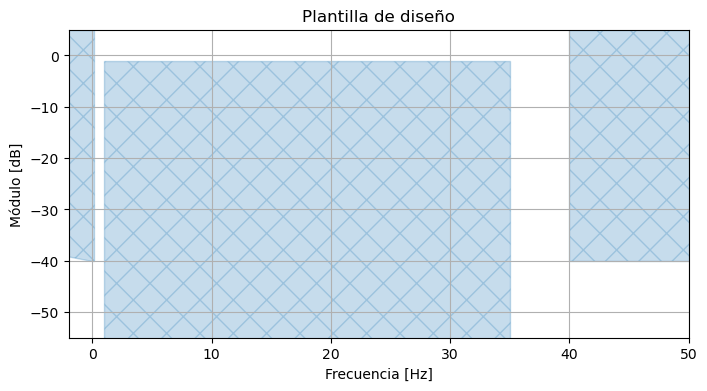

In [9]:
nyq_frec = fs/2
ripple = 1 # dB
atenuacion = 40 # dB
 
ws1v = .1 # Hz
wp1v = 1 # Hz
wp2v = 35 # Hz
ws2v = 40 # Hz

wp = np.array([wp1v, wp2v])
ws = np.array([ws1v, ws2v])

gpass = 1     # dB
gstop = 40     # dB

plt.figure(figsize=(8,4))

#PLANNTILLA
# rechazo inferior
plt.fill( [-100, ws1v, ws1v, 0], [5, 5, -gstop, -gstop], color='C0', alpha=0.25, hatch =  'x')

# banda de paso
plt.fill([wp1v, wp2v, wp2v, wp1v], [-gpass, -gpass, -60, -60],color='C0',alpha=0.25, hatch =  'x' )

# rechazo superior
plt.fill( [ws2v, nyq_frec, nyq_frec, ws2v], [5, 5, -gstop, -gstop], color='C0', alpha=0.25, hatch =  'x')

plt.xlim([-2,50])
plt.ylim([-55,5])

plt.grid(True)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.title('Plantilla de diseño')

## DISEÑO DE FILTROS
Los filtros digitales pueden clasificarse principalmente en FIR (Finite Impulse Response) e IIR (Infinite Impulse Response). Los filtros IIR utilizan realimentación, lo que les permite alcanzar transiciones más abruptas y cumplir especificaciones exigentes con órdenes relativamente bajos. Sin embargo, suelen presentar una respuesta de fase no lineal.

Por otro lado, los filtros FIR poseen una respuesta al impulso de duración finita y pueden diseñarse con fase lineal, característica especialmente valiosa cuando se busca preservar la forma temporal de las señales. Como contrapartida, para cumplir una misma plantilla suelen requerir órdenes significativamente mayores que los filtros IIR.

En las siguientes secciones se diseñarán distintos filtros pertenecientes a ambas familias y se analizará su desempeño en el cumplimiento de la plantilla especificada y en el filtrado de la señal de ECG.


### Filtros  IIR

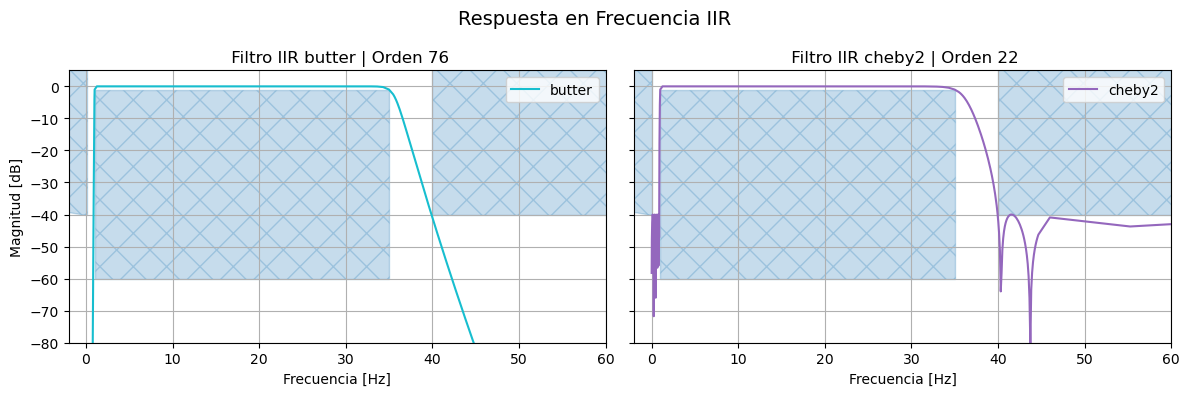

In [10]:
#%% =============================================================================
# # IIR
# =============================================================================
#ftype1='cheby1'
ftype1= 'cheby2'
ftype= 'butter'
#ftype1= 'cauer'

# Requerimientos de plantilla

#filter_type = 'lowpass'
# filter_type = 'highpass'
filter_type = 'bandpass'
# filter_type = 'bandstop'
 
# =============================================================================
# Grilla de evaluacion a medida -> donde poner densidad y donde no
# =============================================================================
ww = np.concat([
    np.logspace (start= -2, stop = 0, num = 200),     #primera transicion
    np. linspace(start = 1.26, stop = 35, num = 50),  # banda de paso
    np.logspace(start = 1.55, stop = 1.65, num = 100),#segunda transicion
    np.linspace(start = 46, stop = fs//2, num = 50)]) #banda de stop
               
sos = signal.iirdesign( wp, ws, gpass, gstop, analog=False, ftype=ftype, output='sos', fs=fs)
sos1 = signal.iirdesign( wp, ws, gpass, gstop, analog=False, ftype=ftype1, output='sos', fs=fs)

orden_ftype = 2 * sos.shape[0]
orden_ftype1 = 2 * sos1.shape[0]

# RESPUESTA EN FRECUENCIA
freqs, resp_freq = signal.sosfreqz( sos, worN=ww, fs=fs)
freqs1, resp_freq1 = signal.sosfreqz( sos1, worN=ww, fs=fs)


# GRAFICO MODULO 
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# FILTRO 1

ax[0].plot(freqs, 20*np.log10(np.abs(resp_freq)+ 1e-12), color='C9', label=ftype)

ax[0].set_title(f' Filtro IIR {ftype} | Orden {orden_ftype}')
ax[0].set_xlabel("Frecuencia [Hz]")
ax[0].set_ylabel("Magnitud [dB]")
ax[0].grid()

# Plantilla
ax[0].fill([-100, ws1v, ws1v, 0], [5, 5, -gstop, -gstop], color='C0', alpha=0.25, hatch='x')

ax[0].fill([wp1v, wp2v, wp2v, wp1v], [-gpass, -gpass, -60, -60], color='C0', alpha=0.25, hatch='x')

ax[0].fill([ws2v, nyq_frec, nyq_frec, ws2v], [5, 5, -gstop, -gstop], color='C0', alpha=0.25, hatch='x')

ax[0].set_xlim([-2, 60])
ax[0].set_ylim([-80, 5])
ax[0].legend()


# FILTRO 2

ax[1].plot(freqs1, 20*np.log10(np.abs(resp_freq1)+ 1e-12),color='C4', label=ftype1)

ax[1].set_title(f' Filtro IIR {ftype1} | Orden {orden_ftype1}')
ax[1].set_xlabel("Frecuencia [Hz]")
ax[1].grid()

# Plantilla
ax[1].fill([-100, ws1v, ws1v, 0], [5, 5, -gstop, -gstop], color='C0', alpha=0.25, hatch='x')

ax[1].fill([wp1v, wp2v, wp2v, wp1v], [-gpass, -gpass, -60, -60], color='C0', alpha=0.25, hatch='x')

ax[1].fill([ws2v, nyq_frec, nyq_frec, ws2v],[5, 5, -gstop, -gstop],color='C0', alpha=0.25, hatch='x')

ax[1].set_xlim([-2, 60])
ax[1].legend()

fig.suptitle("Respuesta en Frecuencia IIR", fontsize=14)
plt.tight_layout()
plt.show()


En los gráficos superiores puede observarse que ambos filtros cumplen satisfactoriamente con las especificaciones de la plantilla, aunque lo hacen mediante estrategias diferentes. El filtro Butterworth presenta una respuesta monótona tanto en la banda de paso como en la banda de rechazo, con una transición suave entre ambas regiones. Por su parte, el filtro Chebyshev tipo II introduce ripple en la banda de rechazo, lo que le permite obtener transiciones más abruptas y cumplir la plantilla con menor complejidad. Como contrapartida, aparecen oscilaciones en la banda de rechazo que pueden acercarse al límite de atenuación especificado.
Esta diferencia se refleja también en el orden requerido por cada aproximación, siendo evidente que el filtro Chebyshev II alcanzó las especificaciones con un orden mucho menor que el Butterworth.

### Filtros  FIR
Para el diseño FIR mediante **ventana** rectangular (Boxcar) fue necesario realizar un preajuste más exigente de la plantilla respecto al caso IIR. Esto se debe a que los filtros FIR son, en general, menos eficientes en términos de orden, requiriendo una mayor cantidad de coeficientes para alcanzar especificaciones similares de atenuación y ancho de transición. Como consecuencia, fue necesario estrechar las bandas de transición durante el diseño para compensar esta

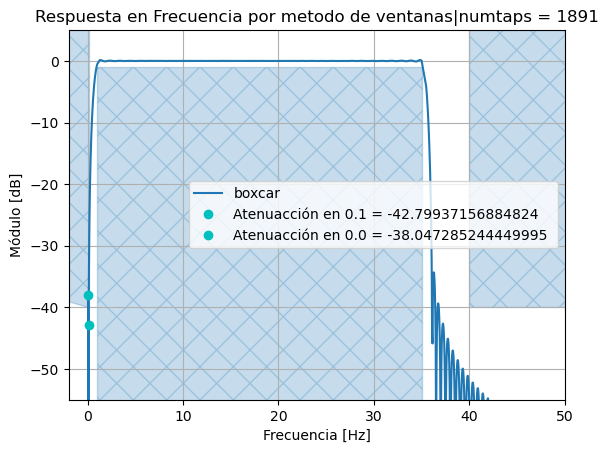

In [184]:
# %%===========================================================================
# # Plantilla para FIR
# # =============================================================================
ws1 = .15 # Hz
wp1 = 1 # Hz
wp2 = 35.15 # Hz
ws2 = 36 # Hz

wpv = np.array([.5, 35])
wsv = np.array([.1, 40])

gpass = 1     # dB
gstop = 40     # dB

window1 = 'hamming'
#window1 = 'hann'
#window1 = 'flattop'
window = 'boxcar'

#filter_type = 'lowpass'
# filter_type = 'highpass'
filter_type = 'bandpass'
# filter_type = 'bandstop'

ww = np.concat([
    np.logspace (start= -2, stop = 0, num = 200),     #primera transicion
    np. linspace(start = 1.26, stop = 35, num = 200),  # banda de paso
    np.logspace(start = 1.55, stop = 1.65, num = 200),#segunda transicion
    np.linspace(start = 46, stop = fs//2, num = 50)]) #banda de stop
               

numtaps = 1891 #ORDEN
freq = np.array([0., ws1, wp1, wp2, ws2, fs//2])
freq1 = np.array([0., 0.4, 0.5, wp2, ws2, fs//2])

# CORRECCIÓN DE GANANCIAS:
# Definimos la plantilla real en dB (0 dB en la banda de paso, -gstop en las de stop)
gains = np.array([0., 0., 1., 1., 0., 0.])


# VENTANA RECTANGULAR  par y simetrico por defecto -> FIR 2 -> CERO EN NYQ -> gains si o si con cero al final
# Forzamos que en Nyquist la ganancia lineal sea exactamente 0
gains[-1] = 0.0
ww_lineal = np.linspace(0, fs//2, 400) #PARA ASEGURAR COMPORTAMIENTO DE FIR

b_win = signal.firwin2(numtaps=numtaps, freq=freq, gain = gains, nfreqs = 2**14, 
                       window = window, antisymmetric=False, fs=fs)

w, h = signal.freqz(b_win, worN = ww , fs=fs)

# =============================================================================
# modulo
# =============================================================================

plt.figure()
plt.plot(w,20*np.log10(np.abs(h)),color='C0', label = f'{window}')

idx = np.argmin(np.abs(w - 0.1))
plt.plot(w[idx], 20*np.log10(np.abs(h[idx])), 'co', label = f'Atenuacción en 0.1 = {20*np.log10(np.abs(h[idx]))} ')

idx = np.argmin(np.abs(w - 0.0))
plt.plot(w[idx], 20*np.log10(np.abs(h[idx])), 'co', label = f'Atenuacción en 0.0 = {20*np.log10(np.abs(h[idx]))} ')

plt.title(f"Respuesta en Frecuencia por metodo de ventanas|numtaps = {numtaps}")

plt.ylabel("Magnitud [dB]")
plt.xlabel("Freq")
plt.grid()

#PLANNTILLA
# rechazo inferior
plt.fill( [-100, ws1v, ws1v, 0], [5, 5, -gstop, -gstop], color='C0', alpha=0.25, hatch =  'x')

# banda de paso
plt.fill([wp1v, wp2v, wp2v, wp1v], [-gpass, -gpass, -60, -60],color='C0',alpha=0.25, hatch =  'x' )

# rechazo superior
plt.fill( [ws2v, nyq_frec, nyq_frec, ws2v], [5, 5, -gstop, -gstop], color='C0', alpha=0.25, hatch =  'x')

plt.xlim([-2,50])
plt.ylim([-55,5])

plt.grid(True)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.legend()
plt.show()



Debido a los elevados lóbulos laterales de la ventana Boxcar, las transiciones angostas representan el caso más desfavorable. En estas regiones, la energía asociada a dichos lóbulos se encuentra más próxima a la banda útil, pudiendo aparecer réplicas que superen el nivel de atenuación requerido. 

El proceso de ajuste de este filtro fue reallizado totalmente a mano de modo experimental, se probó con varias frecuencias de paso y rechazo en la primera transisción para intentar llegar a un resultado pertinente. La transición inferior fué la más problematica ya que debía considerarse el copromiso  entre la pérdida de información valiosa de la banda de paso y la posiblidad de ensuciar el ruido en frecuencias ultrabajas, de esta manera se asumió un compromiso donde el filtro alcanza la atenuación minima en 0.1 pero los lobulos laterales próximos superan por poco esa minima atenuación.
Al mismo tiempo se intentó disminuir orden hasta encontrar un equilibrio de compromisos.


Posteriormente se realizó el mismo proceso con los métodos de **cuadrados minimos** y **Remez** a diferencia de procesos anteriores el método permite ajustar pesos relativos entre bandas para controlar cómo se distribuye el error de aproximación. Esto resulta particularmente útil cuando se desea privilegiar el cumplimiento de ciertas especificaciones, concentrando el ripple en regiones menos críticas de la respuesta.


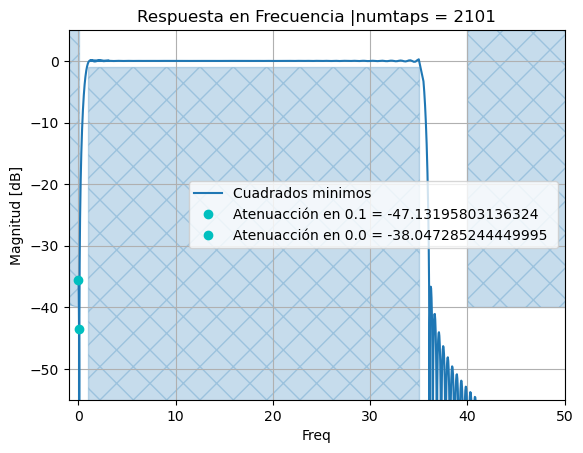

In [186]:

ws1 = .15 # Hz
wp1 = 1 # Hz
wp2 = 35.3 # Hz
ws2 = 36 # Hz

wp = np.array([wp1, wp2])
ws = np.array([ws1, ws2])

wpv = np.array([.5,30])
wsv = np.array([.1,35])


gpass = 1     # dB
gstop = 40     # dB

#window = 'Hamming'
#window = 'Hann'
#window = 'flattop'
window = 'boxcar'

#filter_type = 'lowpass'
# filter_type = 'highpass'
filter_type = 'bandpass'
# filter_type = 'bandstop'

ww = np.concat([
    np.logspace (start= -2, stop = 0.5, num = 200),     #primera transicion
    np. linspace(start = 1.26, stop = 35, num = 200),  # banda de paso
    np.logspace(start = 1.55, stop = 1.65, num = 200),#segunda transicion
    np.linspace(start = 46, stop = fs//2, num = 50)]) #banda de stop
               

numtaps = 2101
freq = np.array([0., ws1,  wp1,  wp2,  ws2,  fs//2])

# CORRECCIÓN DE GANANCIAS:
# Definimos la plantilla real en dB (0 dB en la banda de paso, -gstop en las de stop)
gains = np.array([0., 0., 1., 1., 0., 0.])
weight = [8, 1, 5]

# VENTANA RECTANGULAR  par y simetrico por defecto -> FIR 2 -> CERO EN NYQ -> gains si o si con cero al final
# Forzamos que en Nyquist la ganancia lineal sea exactamente 0
gains[-1] = 0.0
ww_lineal = np.linspace(0, fs//2, 400) #PARA ASEGURAR COMPORTAMIENTO DE 

b_ls = signal.firls(numtaps = numtaps, bands = freq, desired = gains, weight = weight, fs = fs)

w, h_ls = signal.freqz(b_ls, worN = ww , fs=fs)
z, p, k = signal.tf2zpk(b_win, a=1)

# =============================================================================
# modulo
# =============================================================================

plt.figure()
plt.plot(w,20*np.log10(np.abs(h_ls)),color='C0', label = 'Cuadrados minimos')

idx = np.argmin(np.abs(w - 0.1))
plt.plot(w[idx], 20*np.log10(np.abs(h_ls[idx])), 'co', label = f'Atenuacción en 0.1 = {20*np.log10(np.abs(h[idx]))} ')

idx = np.argmin(np.abs(w - 0.0))
plt.plot(w[idx], 20*np.log10(np.abs(h_ls[idx])), 'co', label = f'Atenuacción en 0.0 = {20*np.log10(np.abs(h[idx]))} ')

plt.title(f"Respuesta en Frecuencia |numtaps = {numtaps}")
plt.ylabel("Magnitud [dB]")
plt.xlabel("Freq")
plt.grid()

#PLANNTILLA
# rechazo inferior
plt.fill( [-100, ws1v, ws1v, 0], [5, 5, -gstop, -gstop], color='C0', alpha=0.25, hatch =  'x')

# banda de paso
plt.fill([wp1v, wp2v, wp2v, wp1v], [-gpass, -gpass, -60, -60],color='C0',alpha=0.25, hatch =  'x' )

# rechazo superior
plt.fill( [ws2v, nyq_frec, nyq_frec, ws2v], [5, 5, -gstop, -gstop], color='C0', alpha=0.25, hatch =  'x')

plt.xlim([-1,50])
plt.ylim([-55,5])

plt.legend()
plt.show()


Para la misma plantilla y el mismo preajuste, el método de cuadrados mínimos obtuvo una respuesta muy similar a la observada mediante el diseño por ventanas. Sin embargo, fue necesario incrementar ligeramente el número de coeficientes para alcanzar prestaciones comparables. Dado que el filtro cumple adecuadamente las especificaciones y no presenta diferencias significativas respecto de los casos anteriores, no se profundizará en su análisis.

Por último se realizó un proceso parecido para el método de **Parks-McClellan**:

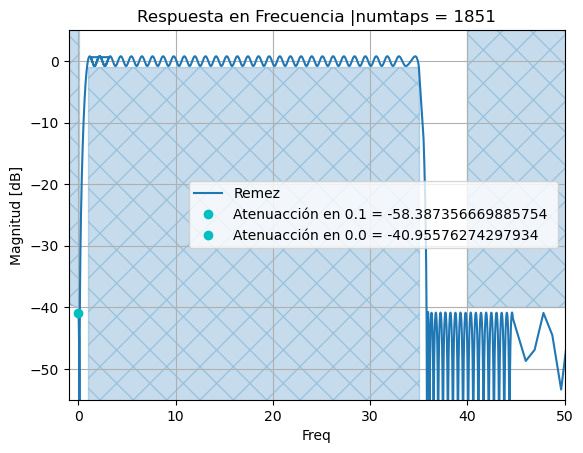

In [202]:
ws1 = .15 # Hz
wp1 = 0.9 # Hz
wp2 = 35 # Hzr
ws2 = 35.8 # Hz

wp = np.array([wp1, wp2])
ws = np.array([ws1, ws2])

wpv = np.array([1,35])
wsv = np.array([.1,45])


gpass = 1     # dB
gstop = 40     # dB

#window = 'Hamming'
#window = 'Hann'
#window = 'flattop'
window = 'boxcar'

#filter_type = 'lowpass'
# filter_type = 'highpass'
filter_type = 'bandpass'
# filter_type = 'bandstop'

ww = np.concat([
    np.logspace (start= -2, stop = 0.5, num = 500),     #primera transicion
    np. linspace(start = 1.26, stop = 35, num = 1000),  # banda de paso
    np.logspace(start = 1.55, stop = 1.65, num = 1000),#segunda transicion
    np.linspace(start = 46, stop = fs//2, num = 500)]) #banda de stop
               

numtaps = 1851
freq = np.array([ 0., ws1,  wp1,  wp2,  ws2,  fs//2])

# CORRECCIÓN DE GANANCIAS:
# Definimos la plantilla real en dB (0 dB en la banda de paso, -gstop en las de stop)
gains = np.array([0., 1., 0.])

gains[-1] = 0.0

b_r = signal.remez(numtaps = numtaps, bands = freq, desired = gains, weight= [5, 0.5, 5], type= filter_type, fs=fs)

w1, hr = signal.freqz(b_r, worN = ww , fs=fs)

# =============================================================================
# modulo
# =============================================================================

plt.figure()
# plt.plot(w,20*np.log10(np.abs(h)),color='C0', label = 'Ventanas')
plt.plot(w1,20*np.log10(np.abs(hr)),color='C0', label = 'Remez')

idx = np.argmin(np.abs(w1 - 0.1))
plt.plot(w[idx], 20*np.log10(np.abs(hr[idx])), 'co', label = f'Atenuacción en 0.1 = {20*np.log10(np.abs(hr[idx]))} ')

idx = np.argmin(np.abs(w1 - 0.0))
plt.plot(w[idx], 20*np.log10(np.abs(hr[idx])), 'co', label = f'Atenuacción en 0.0 = {20*np.log10(np.abs(hr[idx]))} ')

plt.title(f"Respuesta en Frecuencia |numtaps = {numtaps}")
plt.ylabel("Magnitud [dB]")
plt.xlabel("Freq")
plt.grid()

#PLANNTILLA
# rechazo inferior
plt.fill( [-100, ws1v, ws1v, 0], [5, 5, -gstop, -gstop], color='C0', alpha=0.25, hatch =  'x')

# banda de paso
plt.fill([wp1v, wp2v, wp2v, wp1v], [-gpass, -gpass, -60, -60],color='C0',alpha=0.25, hatch =  'x' )

# rechazo superior
plt.fill( [ws2v, nyq_frec, nyq_frec, ws2v], [5, 5, -gstop, -gstop], color='C0', alpha=0.25, hatch =  'x')

plt.xlim([-1,50])
plt.ylim([-55,5])

plt.legend()
plt.show()


A diferencia de lo esperado teóricamente, el algoritmo no logró satisfacer exactamente la atenuación especificada en el borde inferior de la banda de rechazo. A pesar de realizar diversos ajustes manuales sobre los parámetros de diseño, el valor obtenido permaneció cercano a 39.7 dB. Esto sugiere que, para la plantilla adoptada y el orden seleccionado, el algoritmo se encuentra próximo a la solución óptima alcanzable.

Durante el proceso de diseño se realizaron múltiples ajustes manuales sobre los parámetros del algoritmo, incluyendo modificaciones del orden del filtro, de los pesos relativos entre bandas y de la discretización utilizada para la optimización. Sin embargo, dichas modificaciones no produjeron mejoras significativas en este punto particular. Considerando que el desvío observado es inferior a 0.3 dB y se encuentra localizado en el borde de la banda de transición, se considera que el filtro cumple de manera práctica con los requerimientos establecidos.

# Verificacción de comportamientos de filtros en la señal

A continuacion se demostrará como las técnicas empleadas funcionan eficazmente para el arreglo de interferencias relacionadas con la exposición a factores externos e internos relacionadas con el tipo de señal, se busca ver que en señales filtradas la señal presente un patrón que se desarrolle a lo largo de una linea recta.

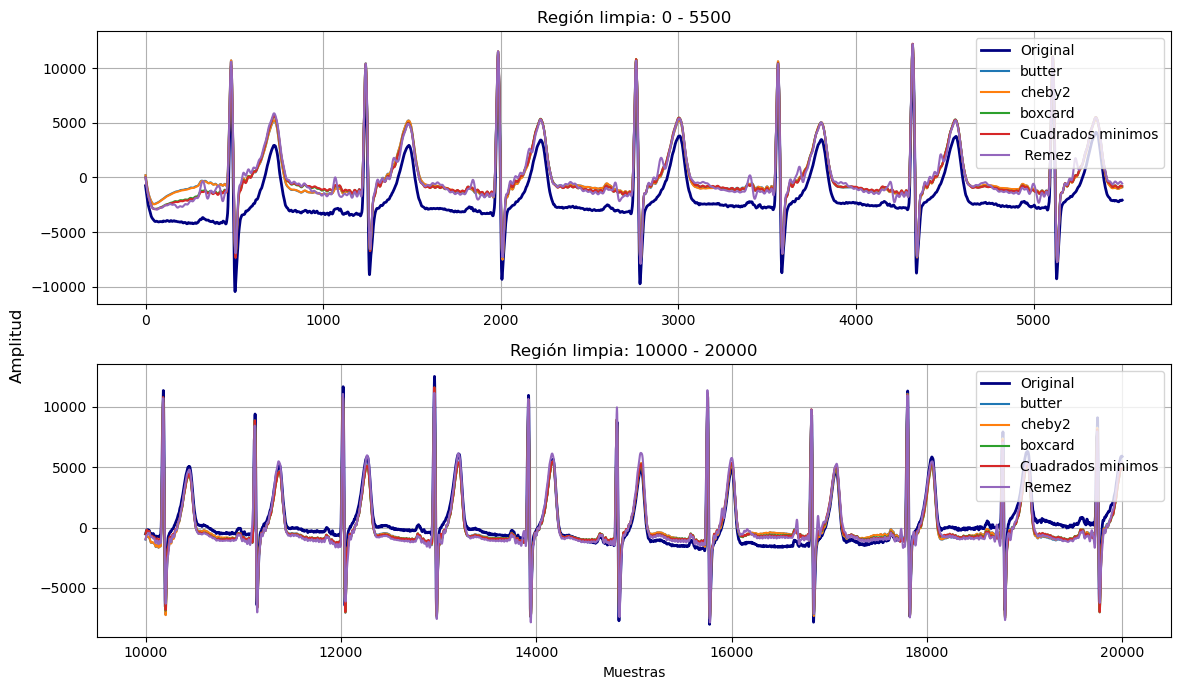

In [208]:
# =============================================================================
# REGIONES SIN RUIDO
# =============================================================================

regs_ruido = ( [0, 5500], [10000, 20000])

fig, ax = plt.subplots(len(regs_ruido), 1, figsize=(12, 7), sharex=False)

for kk, ii in enumerate(regs_ruido):

    zoom_region = np.arange( max(0, ii[0]), min(N, ii[1]), dtype='uint')

    # Señal original
    ax[kk].plot( zoom_region, ecg[zoom_region], color='navy', linewidth=2, label='Original' )

    # IIR
    yy_iir = signal.sosfiltfilt(sos, ecg)
    yy_iir1 = signal.sosfiltfilt(sos1, ecg)
    

    ax[kk].plot( zoom_region, yy_iir[zoom_region], linewidth=1.5, label= f'{ftype}' )
    ax[kk].plot( zoom_region, yy_iir1[zoom_region], linewidth=1.5, label= f'{ftype1}' )
    

    # FIR
    yy_firwin = signal.filtfilt(b_win, [1.0], ecg)
    yy_firls = signal.filtfilt(b_ls, [1.0], ecg)
    yy_firemez = signal.filtfilt(b_r, [1.0], ecg)
    

    ax[kk].plot( zoom_region, yy_firwin[zoom_region], linewidth=1.5, label='boxcard' )
    ax[kk].plot( zoom_region, yy_firls[zoom_region], linewidth=1.5, label='Cuadrados minimos' )
    ax[kk].plot( zoom_region, yy_firemez[zoom_region], linewidth=1.5, label=' Remez' )
    
    

    ax[kk].set_title( f'Región limpia: {ii[0]} - {ii[1]}' )

    ax[kk].grid(True)
    ax[kk].legend()

ax[-1].set_xlabel('Muestras')
fig.supylabel('Amplitud')

plt.tight_layout()
plt.show()

Decidí modificar las regiones sugeridas para incluir un tramo cercano al inicio del registro y poder analizar el comportamiento de los filtros sobre señales con baja presencia de perturbaciones. En estas regiones puede observarse que todos los filtros conservan adecuadamente la morfología de los latidos, manteniendo la forma de los complejos QRS y de las restantes ondas características del ECG.

Asimismo, se aprecia que al comienzo del registro la señal original presenta un leve desplazamiento respecto del nivel isoeléctrico, situación que es corregida por todos los filtros al eliminar componentes de muy baja frecuencia. En las regiones posteriores únicamente se observan pequeñas diferencias de amplitud entre los distintos diseños, sin evidenciar deformaciones significativas sobre la información de interés. Esto permite concluir que los filtros resultan prácticamente inocuos en aquellas zonas donde la señal ya posee una calidad aceptable.

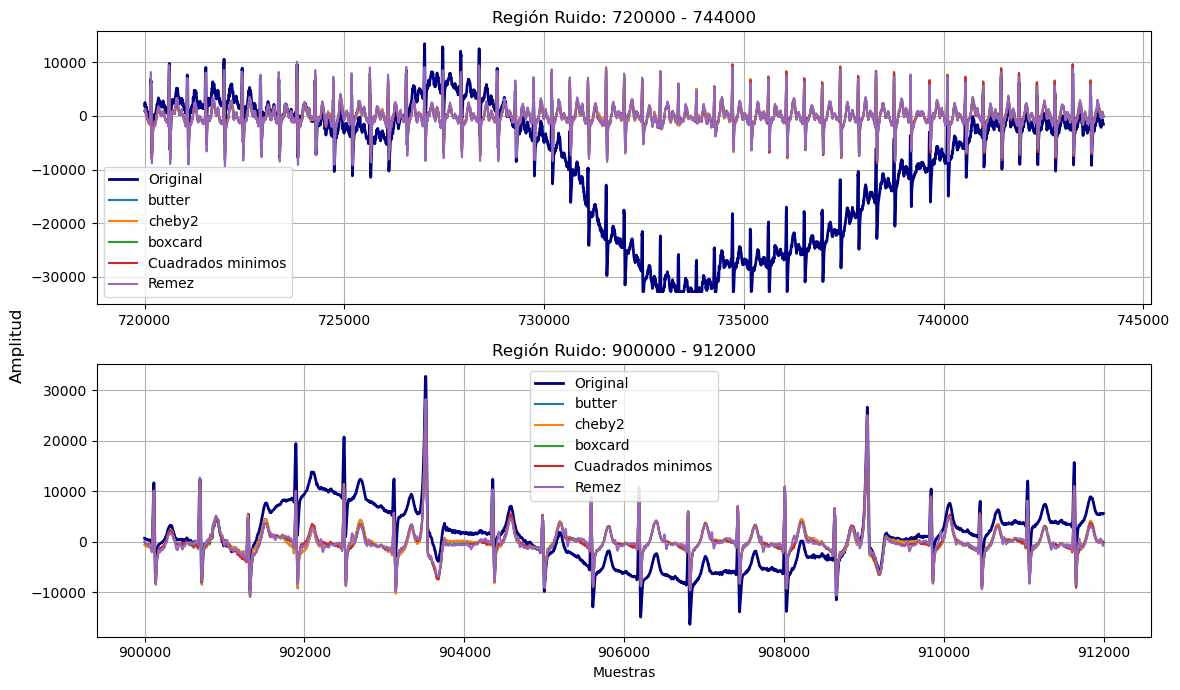

In [209]:
# =============================================================================
# REGIONES CON RUIDO
# =============================================================================

regs_limpias = (
    np.array([12, 12.4]) * 60 * fs, # minutos a muestras
    np.array([15, 15.2]) * 60 * fs, # minutos a muestras
)

fig, ax = plt.subplots(len(regs_limpias), 1,figsize=(12, 7), sharex=False)

for kk, ii in enumerate(regs_limpias):

    zoom_region = np.arange(max(0, int(ii[0])), min(N, int(ii[1])), dtype='uint')

    # Señal original
    ax[kk].plot( zoom_region, ecg[zoom_region], color='navy', linewidth=2, label='Original' )

    # IIR
    yy_iir = signal.sosfiltfilt(sos, ecg)
    yy_iir1 = signal.sosfiltfilt(sos1, ecg)

    ax[kk].plot( zoom_region, yy_iir[zoom_region], linewidth=1.5, label= f'{ftype}')
    ax[kk].plot( zoom_region, yy_iir1[zoom_region], linewidth=1.5, label= f'{ftype1}')
    

    # FIR
    yy_firemez = signal.filtfilt(b_r, [1.0], ecg)
    yy_firwin = signal.filtfilt(b_win, [1.0], ecg)
    yy_firls = signal.filtfilt(b_ls, [1.0], ecg)
    

    ax[kk].plot( zoom_region, yy_firwin[zoom_region], label='boxcard')
    ax[kk].plot( zoom_region, yy_firls[zoom_region], label='Cuadrados minimos' )
    ax[kk].plot( zoom_region, yy_firemez[zoom_region], label='Remez' )

    ax[kk].set_title(
        f'Región Ruido: {int(ii[0])} - {int(ii[1])}'  )

    ax[kk].grid(True)
    ax[kk].legend()

ax[-1].set_xlabel('Muestras')
fig.supylabel('Amplitud')

plt.tight_layout()
plt.show()

A diferencia de lo observado en las regiones anteriores, en estas zonas la señal presenta perturbaciones de gran amplitud dominadas por componentes de muy baja frecuencia. El caso más evidente corresponde a la región comprendida entre las muestras 720000 y 744000, donde la línea de base experimenta una deriva significativa que dificulta la correcta interpretación del ECG.

Puede observarse que todos los filtros diseñados logran eliminar eficazmente esta componente indeseada, recentrando la señal alrededor del nivel isoeléctrico y recuperando la morfología característica de los latidos. Además, las respuestas obtenidas por los distintos métodos resultan muy similares entre sí, lo que indica que, a pesar de las diferencias observadas previamente en términos de orden, ripple y complejidad de diseño, todos cumplen satisfactoriamente el objetivo de mitigación de ruido propuesto.

## Conclusión:

En función de los resultados obtenidos, puede concluirse que todos los filtros diseñados lograron cumplir satisfactoriamente con los requerimientos planteados. En las regiones con baja presencia de perturbaciones conservaron adecuadamente la morfología del ECG, mientras que en las zonas afectadas por ruido consiguieron mitigar de forma efectiva las variaciones de baja frecuencia responsables del desplazamiento de la línea de base. A pesar de las diferencias observadas en complejidad, orden y respuesta en frecuencia, todos los diseños permitieron obtener una señal más limpia y adecuada para su posterior análisis.